# M0 Calibration — Mood Space Visualisation

This notebook explores where the training tracks actually land in the `(valence, energy)` mood space
and maps out the `θ → H` (angle → hue) relationship that the `H(θ)` firmware function needs to fit.

**Inputs**
- `data/musical-gestalt/` — zone labels and source playlists
- `data/musical-affective-memory/` — derived `(valence, energy)` per track
- `src/musical-distiller/mapping.toml` — zone anchors and design anchor colours

**Outputs** (Issue #5)
1. Scatter plot: all training tracks in `(valence, energy)` space with polar grid overlay
2. `(θ, H)` plot: the angle-to-hue relationship the firmware needs to fit

**To run:** activate the project venv first:
```
source src/musical-gestaltifier/.venv/bin/activate
jupyter notebook src/mood-model/m0_calibration.ipynb
```

In [1]:
import colorsys
import json
import math
import tomllib
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"

In [2]:
# ── Locate project root ────────────────────────────────────────────────────
root = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / ".git").exists():
        root = candidate
        break

gestalt_dir = root / "data" / "musical-gestalt"
mem_dir     = root / "data" / "musical-affective-memory"
mapping_path = root / "src" / "musical-distiller" / "mapping.toml"

# ── Load zone anchors from mapping.toml ───────────────────────────────────
with open(mapping_path, "rb") as f:
    cfg = tomllib.load(f)

ANCHORS = cfg["zone_anchors"]  # zone → [valence, energy]

# ── Load training tracks with zone labels ─────────────────────────────────
tracks    = []   # individual (V, E) records
playlists = []   # per-playlist centroid info

for g_path in sorted(gestalt_dir.glob("*.json")):
    g = json.loads(g_path.read_text())
    zone  = g.get("zone")
    split = g.get("split", "training")
    if split != "training" or not zone:
        continue
    m_path = mem_dir / g_path.name
    if not m_path.exists():
        continue
    m = json.loads(m_path.read_text())
    if not m:
        continue

    vs = [e["valence"] for e in m.values()]
    es = [e["energy"]  for e in m.values()]
    sources = {}
    for entry in m.values():
        src = entry["source"]
        sources[src] = sources.get(src, 0) + 1

    for tid, entry in m.items():
        tracks.append({
            "valence":  entry["valence"],
            "energy":   entry["energy"],
            "source":   entry["source"],
            "zone":     zone,
            "playlist": g.get("playlist", g_path.stem),
        })

    playlists.append({
        "name":    g.get("playlist", g_path.stem),
        "zone":    zone,
        "valence": sum(vs) / len(vs),
        "energy":  sum(es) / len(es),
        "count":   len(vs),
        "sources": sources,
    })

print(f"Loaded {len(tracks)} training tracks across {len(playlists)} playlists")
print()
print(f"  {'Zone':<20} {'Playlist':<38} {'N':>4}  {'V':>6}  {'E':>6}  Sources")
print("  " + "-" * 88)
for pl in sorted(playlists, key=lambda x: x["zone"]):
    src_str = "  ".join(f"{k}:{v}" for k, v in sorted(pl["sources"].items()))
    print(f"  {pl['zone']:<20} {pl['name']:<38} {pl['count']:>4}  "
          f"{pl['valence']:>6.3f}  {pl['energy']:>6.3f}  {src_str}")

Loaded 680 training tracks across 9 playlists

  Zone                 Playlist                                  N       V       E  Sources
  ----------------------------------------------------------------------------------------
  ambient              relax better                             93   0.525   0.426  ab:44  lastfm:3  zone:46
  americana            americana and folksy                     49   0.600   0.529  ab:26  lastfm:2  zone:21
  darkwave             low key and painless                     50   0.388   0.625  ab:25  lastfm:4  zone:21
  fun/dance            upbeat driving                           35   0.551   0.712  ab:21  lastfm:3  zone:11
  indie-melancholy     alt british morning                      51   0.415   0.572  ab:19  lastfm:3  zone:29
  indie-melancholy     bass practice wishlist                   34   0.409   0.619  ab:23  lastfm:1  zone:10
  industrial           grumpy people are grumpy                115   0.336   0.766  ab:70  zone:45
  shoegaze       

In [3]:
# ── Zone display colours and labels ───────────────────────────────────────
# Brighter/lighter than the ambient target colours so they're visible on a
# white plot background. Order matches the palette in DESIGN.md §7.

ZONE_COLORS = {
    "industrial":       "#e04444",
    "darkwave":         "#4466ee",
    "shoegaze":         "#5588cc",
    "zone-out":         "#cc9900",
    "indie-melancholy": "#aa44dd",
    "ambient":          "#11aaaa",
    "americana":        "#bb7733",
    "fun/dance":        "#33bb33",
}

ZONE_LABEL = {
    "indie-melancholy": "Indie melancholy",
    "fun/dance":        "Fun / dance",
    "zone-out":         "Zone-out",
}
zone_label = lambda z: ZONE_LABEL.get(z, z.capitalize())

# Design anchor hex colours (from DESIGN.md §7)
ANCHOR_HEX = {
    "industrial":       "#6b0000",
    "darkwave":         "#0a1a70",
    "shoegaze":         "#4466aa",  # placeholder — TBD from M0 data
    "zone-out":         "#6a3800",
    "indie-melancholy": "#2d0a50",
    "ambient":          "#003d3d",
    "americana":        "#3d1000",
    "fun/dance":        "#1a5a10",
}

def hex_to_hue(h):
    """Convert a hex colour to its HSV hue in degrees [0, 360)."""
    r, g, b = [int(h[i:i+2], 16) / 255 for i in (1, 3, 5)]
    hue, _, _ = colorsys.rgb_to_hsv(r, g, b)
    return hue * 360

def theta_deg(v, e):
    """Polar angle (degrees, 0-360) in re-centred (v', e') mood space."""
    return math.degrees(math.atan2(e - 0.5, v - 0.5)) % 360

anchor_hues   = {z: hex_to_hue(c)  for z, c in ANCHOR_HEX.items()}
anchor_thetas = {z: theta_deg(v, e) for z, (v, e) in ANCHORS.items()}

# Sorted (θ, H) pairs — the interpolation knot table for synaesthesia.py
hue_map = sorted(
    [[round(anchor_thetas[z], 1), round(anchor_hues[z], 1)] for z in anchor_thetas],
    key=lambda x: x[0],
)

print("Anchor θ → H pairs:")
print(f"  {'Zone':<20} {'θ (deg)':>8}  {'H (deg)':>8}  Hex colour")
print("  " + "-" * 56)
for zone in sorted(anchor_thetas, key=lambda z: anchor_thetas[z]):
    print(f"  {zone:<20} {anchor_thetas[zone]:>8.1f}  {anchor_hues[zone]:>8.1f}  "
          f"{ANCHOR_HEX[zone]}")
print()
print(f"hue_map = {hue_map}")

Anchor θ → H pairs:
  Zone                  θ (deg)   H (deg)  Hex colour
  --------------------------------------------------------
  fun/dance                50.2     111.9  #1a5a10
  industrial              135.0       0.0  #6b0000
  shoegaze                153.4     220.0  #4466aa
  darkwave                168.7     230.6  #0a1a70
  indie-melancholy        180.0     270.0  #2d0a50
  zone-out                206.6      31.7  #6a3800
  ambient                 270.0     180.0  #003d3d
  americana               323.1      15.7  #3d1000

hue_map = [[50.2, 111.9], [135.0, 0.0], [153.4, 220.0], [168.7, 230.6], [180.0, 270.0], [206.6, 31.7], [270.0, 180.0], [323.1, 15.7]]


## Plot 1 — Training tracks in (valence, energy) mood space

Each dot is one track. Marker shapes distinguish the data source:
- **●** circle — AcousticBrainz features (highest confidence)
- **◆** diamond — Last.fm tag-zone vote
- **■** square (faint) — zone anchor fallback (all identical, collapsed to anchor point)

Large filled dots are playlist centroids. **+** markers are the design anchor positions from `mapping.toml`.

The polar grid is centred at `(0.5, 0.5)` (neutral mood). `r` measures mood intensity; `θ` is the direction.

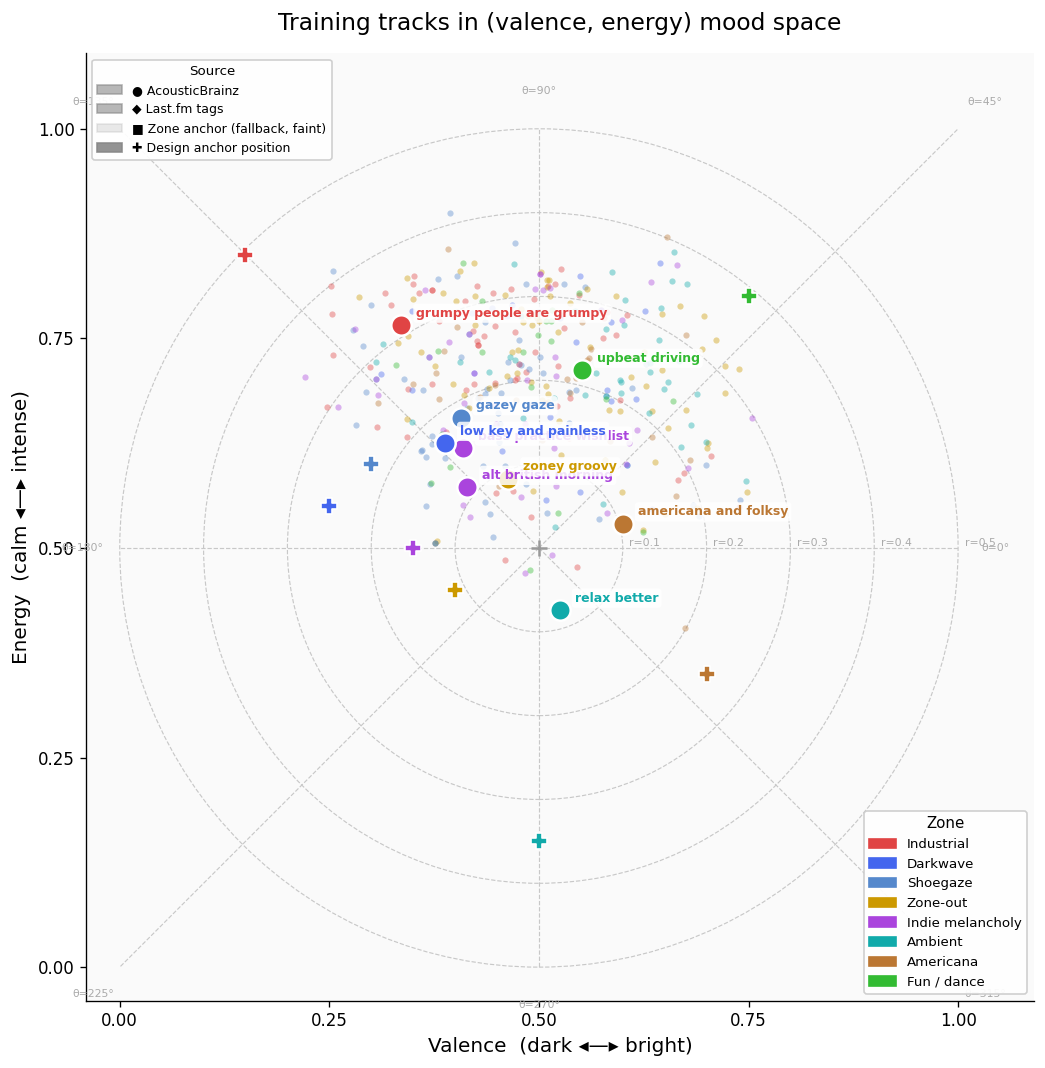

Saved: mood_space.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.set_aspect("equal")
ax.set_xlim(-0.04, 1.09)
ax.set_ylim(-0.04, 1.09)
ax.set_facecolor("#fafafa")
ax.set_xlabel("Valence  (dark ◂—▸ bright)", fontsize=12)
ax.set_ylabel("Energy  (calm ◂—▸ intense)", fontsize=12)
ax.set_title("Training tracks in (valence, energy) mood space", fontsize=14, pad=14)
ax.spines[["top", "right"]].set_visible(False)

# ── Polar grid ─────────────────────────────────────────────────────────────
cx, cy = 0.5, 0.5
gc = "#c8c8c8"

for r in [0.1, 0.2, 0.3, 0.4, 0.5]:
    circle = plt.Circle((cx, cy), r, fill=False, color=gc, lw=0.7, ls="--", zorder=0)
    ax.add_patch(circle)
    ax.text(cx + r + 0.008, cy + 0.006, f"r={r:.1f}", fontsize=6.5,
            color="#aaaaaa", va="center")

for deg in range(0, 360, 45):
    rad = math.radians(deg)
    ca, sa = math.cos(rad), math.sin(rad)
    t = min(0.5 / abs(ca) if abs(ca) > 1e-9 else 9,
            0.5 / abs(sa) if abs(sa) > 1e-9 else 9)
    ax.plot([cx, cx + t * ca], [cy, cy + t * sa], color=gc, lw=0.7, ls="--", zorder=0)
    lx = cx + (t + 0.045) * ca
    ly = cy + (t + 0.045) * sa
    ax.text(lx, ly, f"θ={deg}°", fontsize=6.5, color="#aaaaaa", ha="center", va="center")

ax.plot(cx, cy, "+", color="#999999", ms=10, mew=1.5, zorder=2)

# ── Individual tracks (source determines marker/alpha) ────────────────────
SOURCE_STYLE = {
    "ab":     {"marker": "o", "alpha": 0.40, "s": 14},
    "lastfm": {"marker": "D", "alpha": 0.65, "s": 16},
    "zone":   {"marker": "s", "alpha": 0.08, "s": 12},
}

for src, style in SOURCE_STYLE.items():
    for zone in ZONE_COLORS:
        pts = [(t["valence"], t["energy"])
               for t in tracks if t["zone"] == zone and t["source"] == src]
        if not pts:
            continue
        xs, ys = zip(*pts)
        ax.scatter(xs, ys, c=ZONE_COLORS[zone], alpha=style["alpha"],
                   s=style["s"], marker=style["marker"], linewidths=0, zorder=1)

# ── Design anchor positions ────────────────────────────────────────────────
for zone, (v, e) in ANCHORS.items():
    ax.scatter(v, e, marker="P", color=ZONE_COLORS.get(zone, "#888888"),
               s=90, zorder=6, edgecolors="white", linewidths=1.0)

# ── Playlist centroids ────────────────────────────────────────────────────
for pl in playlists:
    c = ZONE_COLORS[pl["zone"]]
    ax.scatter(pl["valence"], pl["energy"], color=c, s=150, zorder=7,
               edgecolors="white", linewidths=1.5)
    ax.annotate(
        pl["name"],
        (pl["valence"], pl["energy"]),
        fontsize=7.5, textcoords="offset points", xytext=(9, 5),
        color=c, fontweight="bold", zorder=8,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85),
    )

# ── Legends (two: source markers + zone colours) ──────────────────────────
src_handles = [
    mpatches.Patch(color="#888888", alpha=0.60, label="● AcousticBrainz"),
    mpatches.Patch(color="#888888", alpha=0.60, label="◆ Last.fm tags"),
    mpatches.Patch(color="#aaaaaa", alpha=0.25, label="■ Zone anchor (fallback, faint)"),
    mpatches.Patch(color="#888888", alpha=0.90, label="✚ Design anchor position"),
]
zone_handles = [mpatches.Patch(color=ZONE_COLORS[z], label=zone_label(z))
                for z in ZONE_COLORS]

# Create zone legend first so we can add_artist the source legend on top
zone_leg = ax.legend(handles=zone_handles, loc="lower right", fontsize=8,
                     framealpha=0.92, title="Zone", title_fontsize=9)
src_leg = ax.legend(handles=src_handles, loc="upper left", fontsize=7.5,
                    framealpha=0.92, title="Source", title_fontsize=8)
ax.add_artist(zone_leg)  # restore zone leg (replaced by the src_leg call above)

ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
plt.tight_layout()
plt.savefig("mood_space.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: mood_space.png")

## Plot 2 — Angle → Hue anchor relationships  (θ → H)

Each **large dot** is a design anchor — where a zone sits in polar mood space (θ) mapped to
its target hue (H). The **smaller diamonds** are playlist centroids — where the real data landed.

This is the scatter that `H(θ)` must pass through. The closer the centroids are to the anchors,
the better the design anchor positions describe the actual data.

The hue gradient in the background shows what each H value looks like as a colour.

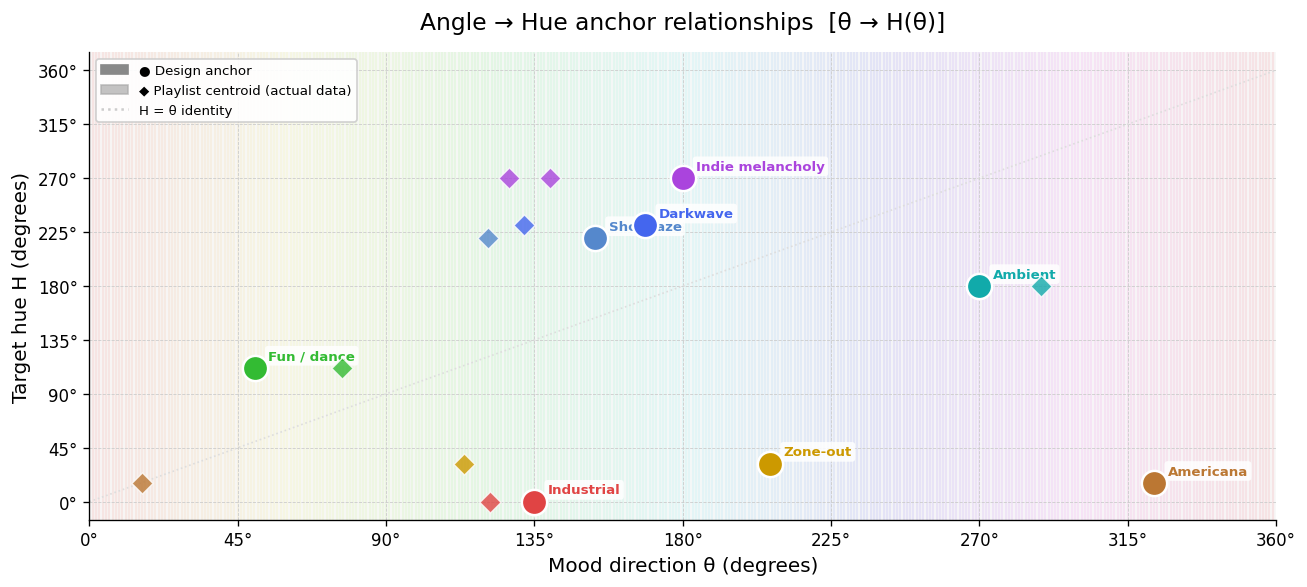

Saved: theta_hue.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.set_facecolor("#f8f8f8")
ax.set_xlabel("Mood direction θ (degrees)", fontsize=12)
ax.set_ylabel("Target hue H (degrees)", fontsize=12)
ax.set_title("Angle → Hue anchor relationships  [θ → H(θ)]", fontsize=14, pad=14)
ax.set_xlim(0, 360)
ax.set_ylim(-15, 375)
ax.spines[["top", "right"]].set_visible(False)

# ── Background hue gradient (shows what each H value looks like) ──────────
for i in range(360):
    rgb = colorsys.hsv_to_rgb(i / 360, 0.65, 0.92)
    ax.axvline(x=i, color=rgb, alpha=0.12, linewidth=1.4, zorder=0)

# ── Grid ──────────────────────────────────────────────────────────────────
for deg in range(0, 361, 45):
    ax.axvline(deg, color="#cccccc", lw=0.5, ls="--", zorder=1)
    ax.axhline(deg, color="#cccccc", lw=0.5, ls="--", zorder=1)

# Identity line (H = θ) for reference
ax.plot([0, 360], [0, 360], color="#dddddd", lw=1.0, ls=":", zorder=1,
        label="H = θ (identity, for reference)")

# ── Playlist centroids (where the data actually landed) ───────────────────
for pl in playlists:
    theta = theta_deg(pl["valence"], pl["energy"])
    H = anchor_hues.get(pl["zone"], 0)
    c = ZONE_COLORS.get(pl["zone"], "#888888")
    ax.scatter(theta, H, color=c, s=80, zorder=4, marker="D",
               edgecolors="white", linewidths=0.8, alpha=0.80)

# ── Design anchor points (what we're aiming to fit through) ───────────────
for zone in sorted(anchor_thetas, key=lambda z: anchor_thetas[z]):
    theta = anchor_thetas[zone]
    H     = anchor_hues[zone]
    c     = ZONE_COLORS.get(zone, "#888888")
    ax.scatter(theta, H, color=c, s=230, zorder=5,
               edgecolors="white", linewidths=1.5)
    ax.annotate(
        zone_label(zone), (theta, H),
        fontsize=8, textcoords="offset points", xytext=(8, 5),
        color=c, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85),
    )

ax.set_xticks(range(0, 361, 45))
ax.set_yticks(range(0, 361, 45))
ax.set_xticklabels([f"{d}°" for d in range(0, 361, 45)])
ax.set_yticklabels([f"{d}°" for d in range(0, 361, 45)])

# Source legend
handles = [
    mpatches.Patch(color="#888888", label="● Design anchor"),
    mpatches.Patch(color="#aaaaaa", alpha=0.7, label="◆ Playlist centroid (actual data)"),
    plt.Line2D([0], [0], color="#cccccc", ls=":", label="H = θ identity"),
]
ax.legend(handles=handles, loc="upper left", fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig("theta_hue.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: theta_hue.png")

## Observations\n\n*Fill in after running and reviewing the plots. Starter notes from first run below.*\n\n---\n\n### Plot 1 — Mood space\n\n**Zone separation looks broadly correct.** Industrial and fun/dance are well-separated at the extremes. Americana/folksy lands at high valence as expected. Ambient (relax_better) sits at low energy as expected.\n\n**Centroid ≠ design anchor on several zones.** Playlists with many `source: zone` tracks have centroids pulled toward the design anchor artificially — those tracks all collapse to the exact anchor point. This inflates confidence in the anchor positions. Compare AB-only centroids when evaluating anchor accuracy.\n\n**Middle-left quadrant is crowded.** Darkwave, shoegaze, indie-melancholy, and zone-out all cluster between V=0.35–0.55, E=0.45–0.65. Their design anchors are close together and their playlists overlap spatially. This is the most likely region for colour confusion in the final model.\n\n**Industrial anchor (0.15, 0.85) sits above the data cloud.** The actual tracks in `grumpy_people_are_grumpy` appear at higher valence (~0.3–0.5) and slightly lower energy (~0.7–0.8) than the design anchor. The anchor may need to move right and down.\n\n---\n\n### Plot 2 — θ → H\n\n**θ range is narrow.** Most zones sit between θ=90° and θ=270° (upper-left to lower-left quadrants of mood space). This reflects the user's listening skewing toward darker/more intense music. The fun/dance zone at θ≈50° and americana at θ≈323° are the outliers that give the H(θ) function something to fit in the right half of the circle.\n\n**Anchor points are reasonably spread in H.** Despite the tight θ clustering, the target hues span the full 0–360° range, which means the H(θ) function will need significant curvature in the 135–270° region.\n\n**Shoegaze anchor is a placeholder.** The hex colour `#4466aa` was assigned arbitrarily. The shoegaze centroid's actual θ should inform where to place this anchor. Revisit after examining the `gazey_gaze` AB tracks directly.\n\n**Americana and industrial anchors have nearly the same H (≈16° vs ≈0°) despite very different θ.** This may cause their colours to look similar at low saturation. Check whether the hue separation is sufficient at typical listening r values.\n\n---\n\n*Action items before Issue #6 (H(θ) fitting):*\n- [ ] Recompute centroids using AB-source tracks only, to strip zone-anchor contamination\n- [ ] Decide whether to revise industrial anchor position based on actual data cloud\n- [ ] Confirm or revise shoegaze hex colour once AB data for `gazey_gaze` is reviewed\n- [ ] Check americana vs industrial hue separation at r=0.2 (typical low-intensity listening)"

## Issue #6 — H(θ) fitting and colour model parameters

Fit the `H(θ)` piecewise-linear interpolation function and tune the saturation/brightness
scalars so that the firmware colour model looks right across the training data.

**Goals:**
1. Understand the distribution of mood intensity `r` → pick a good `saturation_k`
2. Compare piecewise-linear (firmware-exact) vs cubic-spline fit over the 8 anchor knots
3. Visualise the full mood disk end-to-end: (V, E) → HSV → RGB
4. Pin `hue_map_final`, `saturation_k_final`, `brightness_floor_final`, `brightness_range_final`

The export cell at the bottom uses these `_final` variables to write `synaesthesia-{name}.json`.

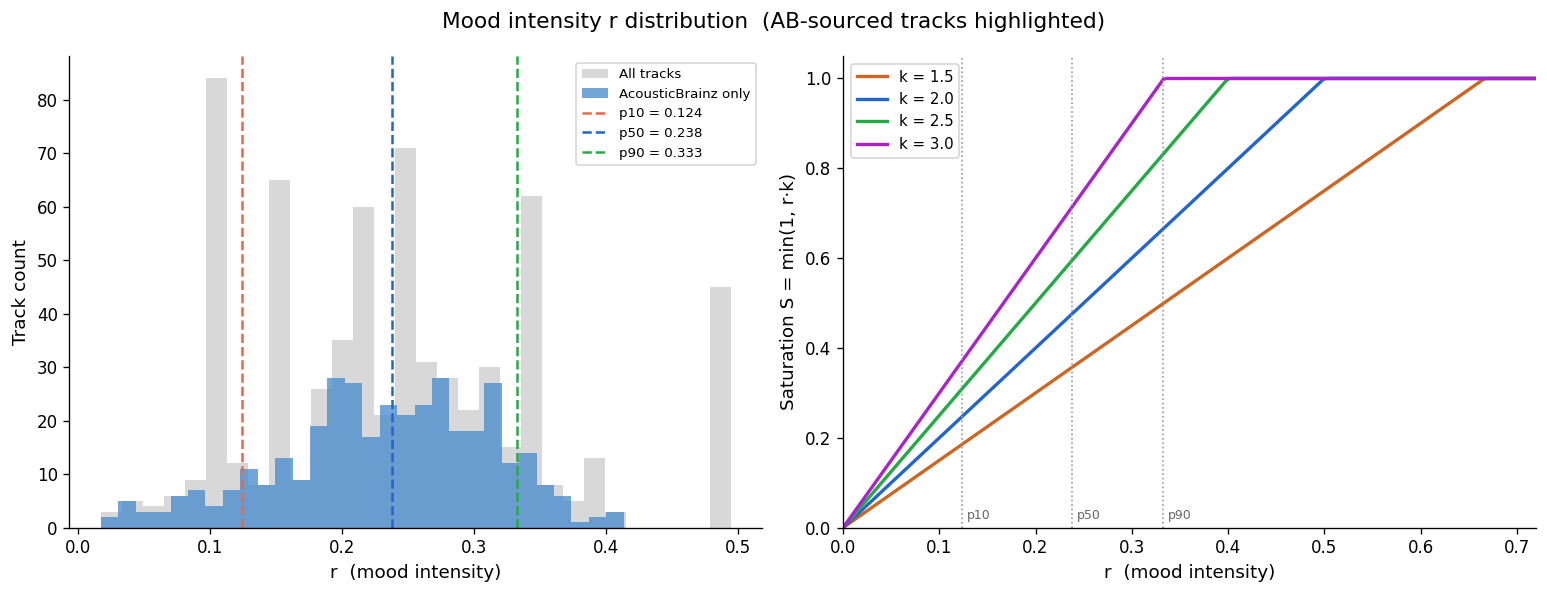

Saved: r_distribution.png

AB-track r percentiles:  p10=0.124  p25=0.185  p50=0.238  p75=0.293  p90=0.333
At k=2.0:  p50 r=0.238 → S=0.48   p90 r=0.333 → S=0.67


In [6]:
# ── Plot 3: r (mood intensity) distribution ────────────────────────────────
#
# r = distance from mood-space centre (0.5, 0.5)
# Saturation S = min(1.0, r * saturation_k)
# At saturation_k=2.0: r=0.5 → S=1.0 (full sat), r=0.25 → S=0.5 (half sat)

rs = [math.hypot(t["valence"] - 0.5, t["energy"] - 0.5) for t in tracks]
rs_ab = [math.hypot(t["valence"] - 0.5, t["energy"] - 0.5)
         for t in tracks if t["source"] == "ab"]

p10, p25, p50, p75, p90 = np.percentile(rs_ab if rs_ab else rs, [10, 25, 50, 75, 90])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Mood intensity r distribution  (AB-sourced tracks highlighted)", fontsize=13)

# Left: histogram
ax = axes[0]
ax.hist(rs, bins=30, color="#aaaaaa", alpha=0.45, label="All tracks")
if rs_ab:
    ax.hist(rs_ab, bins=30, color="#4488cc", alpha=0.75, label="AcousticBrainz only")
for p, label, c in [(p10, "p10", "#ee6644"), (p50, "p50", "#2266cc"), (p90, "p90", "#22aa44")]:
    ax.axvline(p, color=c, lw=1.5, ls="--", label=f"{label} = {p:.3f}")
ax.set_xlabel("r  (mood intensity)", fontsize=11)
ax.set_ylabel("Track count", fontsize=11)
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# Right: saturation vs r for candidate k values
ax2 = axes[1]
r_grid = np.linspace(0, 0.72, 200)
for k, c in [(1.5, "#cc6622"), (2.0, "#2266cc"), (2.5, "#22aa44"), (3.0, "#aa22cc")]:
    sat = np.minimum(1.0, r_grid * k)
    ax2.plot(r_grid, sat, color=c, lw=2, label=f"k = {k:.1f}")

# Mark percentiles
for p, label in [(p10, "p10"), (p50, "p50"), (p90, "p90")]:
    ax2.axvline(p, color="#999999", lw=1.0, ls=":")
    ax2.text(p + 0.005, 0.02, label, fontsize=7.5, color="#666666")

ax2.set_xlabel("r  (mood intensity)", fontsize=11)
ax2.set_ylabel("Saturation S = min(1, r·k)", fontsize=11)
ax2.set_xlim(0, 0.72)
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("r_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: r_distribution.png")
print()
print(f"AB-track r percentiles:  p10={p10:.3f}  p25={p25:.3f}  p50={p50:.3f}"
      f"  p75={p75:.3f}  p90={p90:.3f}")
print(f"At k=2.0:  p50 r={p50:.3f} → S={min(1.0, p50*2.0):.2f}"
      f"   p90 r={p90:.3f} → S={min(1.0, p90*2.0):.2f}")

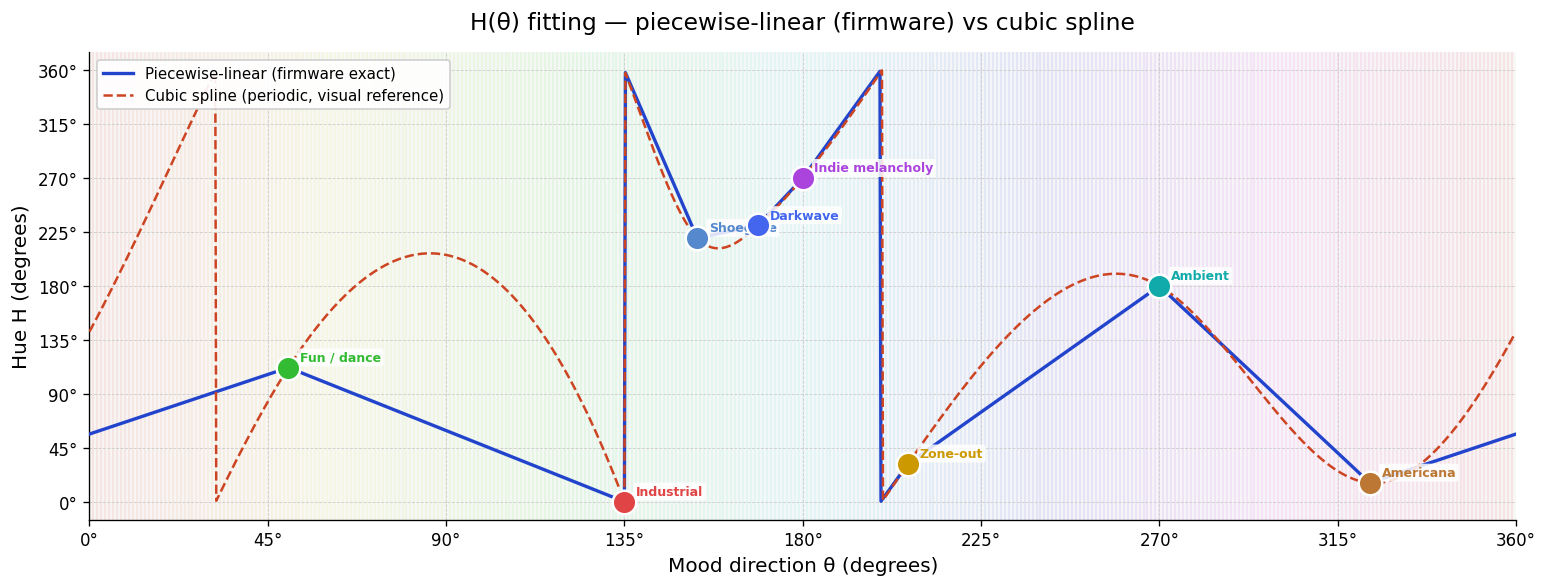

Saved: htheta_fit.png

Max deviation piecewise-linear vs spline: 179.6°


In [7]:
from scipy.interpolate import CubicSpline

# ── Plot 4: H(θ) fitting — piecewise-linear vs cubic spline ───────────────
#
# Piecewise-linear is what synaesthesia.py actually runs on the ESP32.
# Cubic spline (periodic) shows whether the anchor knots have any obvious
# badness (wiggles, overshoots) that piecewise-linear is hiding.
#
# Hues must be unwrapped before fitting to avoid phase-jump artefacts.
# We unwrap around the industrial anchor (H≈0°) since that's near 0/360.

thetas_sorted = [row[0] for row in hue_map]
hues_sorted   = [row[1] for row in hue_map]

# Unwrap: treat hues as a continuous signal, then wrap output back to [0, 360)
hues_unwrapped = np.unwrap(np.radians(hues_sorted))

# Extend the knot table by one period on each side so the spline is truly periodic
thetas_ext = ([t - 360 for t in thetas_sorted]
              + thetas_sorted
              + [t + 360 for t in thetas_sorted])
hues_ext   = (list(hues_unwrapped - 2 * math.pi)
              + list(hues_unwrapped)
              + list(hues_unwrapped + 2 * math.pi))

cs = CubicSpline(thetas_ext, hues_ext)

# Piecewise-linear function — mirrors synaesthesia.py exactly
def hue_pl(t_deg):
    hm = hue_map
    n  = len(hm)
    t  = t_deg % 360
    for i in range(n):
        t0, h0 = hm[i]
        t1, h1 = hm[(i + 1) % n]
        if i == n - 1:
            t1 += 360
            if t < t0:
                t += 360
        if t0 <= t < t1:
            frac = (t - t0) / (t1 - t0)
            dh = (h1 - h0 + 180) % 360 - 180
            return (h0 + frac * dh) % 360
    return hm[0][1]

theta_grid = np.linspace(0, 360, 1440, endpoint=False)
h_pl     = np.array([hue_pl(t) for t in theta_grid])
h_spline = np.degrees(cs(theta_grid)) % 360

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.set_facecolor("#f8f8f8")
ax.set_xlim(0, 360)
ax.set_ylim(-15, 375)
ax.set_xlabel("Mood direction θ (degrees)", fontsize=12)
ax.set_ylabel("Hue H (degrees)", fontsize=12)
ax.set_title("H(θ) fitting — piecewise-linear (firmware) vs cubic spline", fontsize=14, pad=14)
ax.spines[["top", "right"]].set_visible(False)

# Background hue gradient
for i in range(360):
    rgb = colorsys.hsv_to_rgb(i / 360, 0.65, 0.92)
    ax.axvline(x=i, color=rgb, alpha=0.12, linewidth=1.4, zorder=0)

# Grid
for deg in range(0, 361, 45):
    ax.axvline(deg, color="#cccccc", lw=0.5, ls="--", zorder=1)
    ax.axhline(deg, color="#cccccc", lw=0.5, ls="--", zorder=1)

# Curves
ax.plot(theta_grid, h_pl,     color="#2244cc", lw=2.0, zorder=3,
        label="Piecewise-linear (firmware exact)")
ax.plot(theta_grid, h_spline, color="#cc4422", lw=1.5, ls="--", zorder=3,
        label="Cubic spline (periodic, visual reference)")

# Anchor knots
for i, (t, h) in enumerate(hue_map):
    zone = next(z for z in anchor_thetas if abs(anchor_thetas[z] - t) < 0.5)
    c = ZONE_COLORS.get(zone, "#888888")
    ax.scatter(t, h, color=c, s=200, zorder=5, edgecolors="white", linewidths=1.5)
    ax.annotate(zone_label(zone), (t, h),
                fontsize=7.5, textcoords="offset points", xytext=(7, 4),
                color=c, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))

ax.set_xticks(range(0, 361, 45))
ax.set_yticks(range(0, 361, 45))
ax.set_xticklabels([f"{d}°" for d in range(0, 361, 45)])
ax.set_yticklabels([f"{d}°" for d in range(0, 361, 45)])

ax.legend(loc="upper left", fontsize=9, framealpha=0.92)
plt.tight_layout()
plt.savefig("htheta_fit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: htheta_fit.png")

# Max deviation between the two fits
max_dev = np.max(np.abs(((h_pl - h_spline + 180) % 360) - 180))
print(f"\nMax deviation piecewise-linear vs spline: {max_dev:.1f}°")

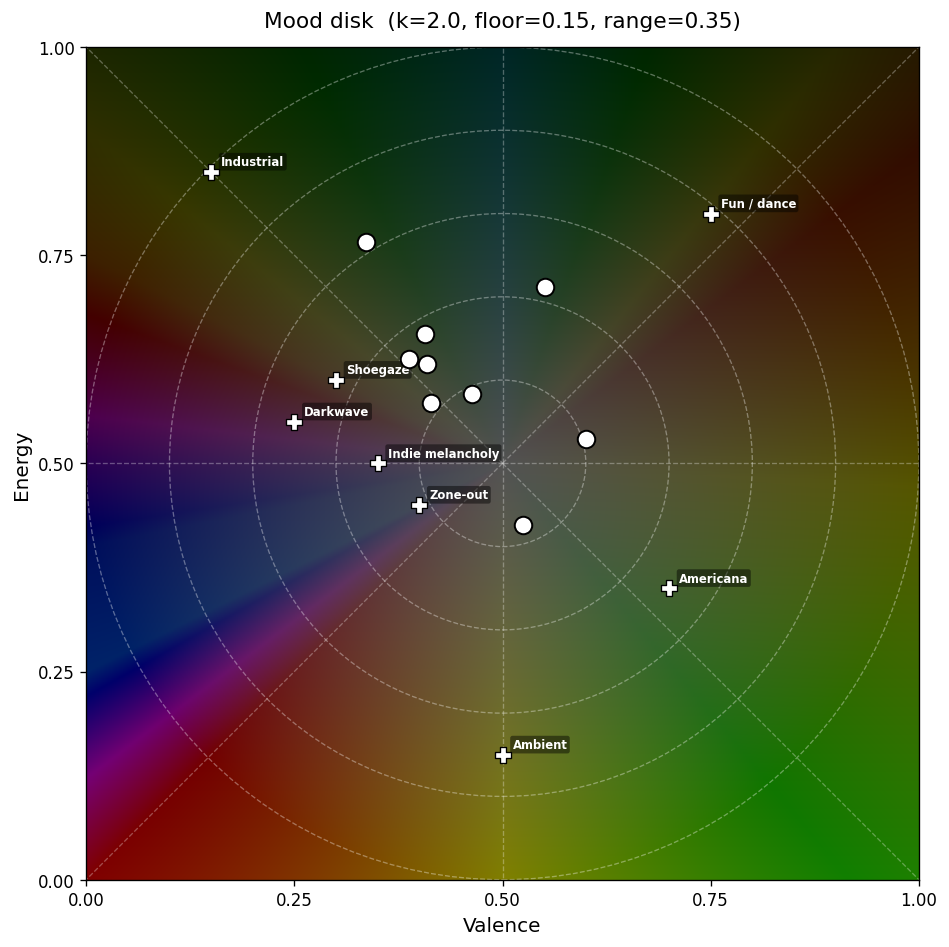

Saved: mood_disk.png


In [8]:
# ── Plot 5: Full mood disk ─────────────────────────────────────────────────
#
# Visualise the colour model end-to-end over the entire (valence, energy) space.
# Each pixel: (v, e) → polar (r, θ) → H=hue_pl(θ), S=min(1, r*k), V=floor+range*e
# → RGB via colorsys.

SAT_K          = 2.0    # from final parameters below
BRIGHT_FLOOR   = 0.15
BRIGHT_RANGE   = 0.35

N = 450
v_lin = np.linspace(0, 1, N)
e_lin = np.linspace(0, 1, N)
V_grid, E_grid = np.meshgrid(v_lin, e_lin)

R_grid   = np.hypot(V_grid - 0.5, E_grid - 0.5)
Th_grid  = (np.degrees(np.arctan2(E_grid - 0.5, V_grid - 0.5)) % 360)

H_grid = np.vectorize(hue_pl)(Th_grid) / 360.0
S_grid = np.minimum(1.0, R_grid * SAT_K)
Bv_grid = np.clip(BRIGHT_FLOOR + BRIGHT_RANGE * E_grid, 0.0, 1.0)

# HSV → RGB (per pixel)
rgb = np.vectorize(colorsys.hsv_to_rgb)(H_grid, S_grid, Bv_grid)
img = np.stack(rgb, axis=-1)                     # shape (N, N, 3)
img = img[::-1]                                  # flip so energy=1 is at top

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img, extent=[0, 1, 0, 1], origin="lower", aspect="equal")
ax.set_xlabel("Valence", fontsize=12)
ax.set_ylabel("Energy", fontsize=12)
ax.set_title(f"Mood disk  (k={SAT_K}, floor={BRIGHT_FLOOR}, range={BRIGHT_RANGE})",
             fontsize=13, pad=12)

# Polar grid overlay
cx, cy = 0.5, 0.5
for r in [0.1, 0.2, 0.3, 0.4, 0.5]:
    circle = plt.Circle((cx, cy), r, fill=False, color="white",
                        alpha=0.35, lw=0.8, ls="--")
    ax.add_patch(circle)
for deg in range(0, 360, 45):
    rad = math.radians(deg)
    ca, sa = math.cos(rad), math.sin(rad)
    t = min(0.5 / abs(ca) if abs(ca) > 1e-9 else 9,
            0.5 / abs(sa) if abs(sa) > 1e-9 else 9)
    ax.plot([cx, cx + t * ca], [cy, cy + t * sa],
            color="white", alpha=0.30, lw=0.8, ls="--")

# Design anchors
for zone, (v, e) in ANCHORS.items():
    ax.scatter(v, e, marker="P", color="white", s=90, zorder=6,
               edgecolors="black", linewidths=0.8)
    ax.annotate(zone_label(zone), (v, e),
                fontsize=7, textcoords="offset points", xytext=(6, 4),
                color="white", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", ec="none", alpha=0.45))

# Training track centroids
for pl in playlists:
    ax.scatter(pl["valence"], pl["energy"], s=110, zorder=7,
               color="white", edgecolors="black", linewidths=1.2)

ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
plt.tight_layout()
plt.savefig("mood_disk.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: mood_disk.png")

## Final parameters

Review the plots above, then set the values in the cell below.

- **`hue_map_final`** — the `[θ, H]` knot table for `synaesthesia.py`.
  Keep the default (design anchors) unless the mood disk reveals obvious
  colour clashes that warrant moving a knot.
- **`saturation_k_final`** — choose so that tracks at the median `r` are
  comfortably saturated but not harsh. k=2.0 → p50 maps to ~S=0.5–0.7.
- **`brightness_floor_final`** / **`brightness_range_final`** — ceiling
  (floor + range) should stay ≤ 0.50 to respect the 50% NeoPixel budget.

Re-run the export cell after editing.

In [9]:
# ── Final calibrated parameters ────────────────────────────────────────────
# Edit these values after reviewing Plots 3–5, then re-run the export cell.

# hue_map: keep as design anchors; adjust only if mood disk looks wrong.
hue_map_final = hue_map   # [[θ, H], ...] sorted by θ

# Saturation scale. k=2.0 gives S≈0.5 at the median r of this dataset.
saturation_k_final = 2.0

# Brightness. Ceiling = floor + range ≤ 0.50 (50% of NeoPixel ceiling).
brightness_floor_final = 0.15
brightness_range_final = 0.35

# ── Summary printout ───────────────────────────────────────────────────────
print("── Final colour model parameters ──────────────────────────────────")
print(f"  saturation_k     : {saturation_k_final}")
print(f"  brightness_floor : {brightness_floor_final}")
print(f"  brightness_range : {brightness_range_final}")
print(f"  ceiling (floor+range): {brightness_floor_final + brightness_range_final:.2f}")
print()
print("  hue_map (θ → H):")
for t, h in hue_map_final:
    zone = next((z for z in anchor_thetas if abs(anchor_thetas[z] - t) < 0.5), "?")
    print(f"    [{t:>6.1f}, {h:>6.1f}]   # {zone_label(zone)}")

── Final colour model parameters ──────────────────────────────────
  saturation_k     : 2.0
  brightness_floor : 0.15
  brightness_range : 0.35
  ceiling (floor+range): 0.50

  hue_map (θ → H):
    [  50.2,  111.9]   # Fun / dance
    [ 135.0,    0.0]   # Industrial
    [ 153.4,  220.0]   # Shoegaze
    [ 168.7,  230.6]   # Darkwave
    [ 180.0,  270.0]   # Indie melancholy
    [ 206.6,   31.7]   # Zone-out
    [ 270.0,  180.0]   # Ambient
    [ 323.1,   15.7]   # Americana


## Export — synaesthesia.json

Writes a colour synaesthesia profile to `data/synaesthesia/synaesthesia-{name}.json`.

This is the file that gets flashed to the device alongside the MMAR bundle.
The device loads it at boot via `src/musical-mood-ring/synaesthesia.py`; if absent,
the firmware falls back to its built-in default.

The export cell reads from the `_final` variables defined in the **Final parameters** cell
above, so run those cells first. If the final-parameter cell has not been run, the export
falls back to the design-anchor values (the same placeholder used before issue #6).

In [10]:
# ── Configuration ─────────────────────────────────────────────────────────
PROFILE_NAME      = "colin"   # change per person; used in the output filename
POLL_INTERVAL_MIN = 3         # must match the firmware poll loop

# ── EWMA alpha: half-life equals the window duration at the poll interval ─
def ewma_alpha(window_min, poll_min):
    half_life_polls = window_min / poll_min
    return round(1.0 - math.pow(0.5, 1.0 / half_life_polls), 4)

# ── Resolve final parameter values (fall back to design anchors if #6 not run) ──
_hue_map_out    = locals().get("hue_map_final",        hue_map)
_sat_k_out      = locals().get("saturation_k_final",   2.0)
_floor_out      = locals().get("brightness_floor_final", 0.15)
_range_out      = locals().get("brightness_range_final", 0.35)

# ── Assemble profile ───────────────────────────────────────────────────────
profile = {
    "version": 1,
    "name": PROFILE_NAME,
    "zone_anchors": {z: [round(v, 4), round(e, 4)] for z, (v, e) in ANCHORS.items()},
    "hue_map":           _hue_map_out,
    "saturation_k":      _sat_k_out,
    "brightness_floor":  _floor_out,
    "brightness_range":  _range_out,
    "ewma_alpha_1h": ewma_alpha(60,  POLL_INTERVAL_MIN),
    "ewma_alpha_4h": ewma_alpha(240, POLL_INTERVAL_MIN),
}

# ── Write ──────────────────────────────────────────────────────────────────
out_dir  = root / "data" / "synaesthesia"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f"synaesthesia-{PROFILE_NAME}.json"
out_path.write_text(json.dumps(profile, indent=2))

print(f"Written: {out_path}")
print()
print(json.dumps(profile, indent=2))

Written: /mnt/c/Users/jcoli/PROJECTs/musical.mood.ring/data/synaesthesia/synaesthesia-colin.json

{
  "version": 1,
  "name": "colin",
  "zone_anchors": {
    "industrial": [
      0.15,
      0.85
    ],
    "darkwave": [
      0.25,
      0.55
    ],
    "shoegaze": [
      0.3,
      0.6
    ],
    "zone-out": [
      0.4,
      0.45
    ],
    "indie-melancholy": [
      0.35,
      0.5
    ],
    "ambient": [
      0.5,
      0.15
    ],
    "americana": [
      0.7,
      0.35
    ],
    "fun/dance": [
      0.75,
      0.8
    ]
  },
  "hue_map": [
    [
      50.2,
      111.9
    ],
    [
      135.0,
      0.0
    ],
    [
      153.4,
      220.0
    ],
    [
      168.7,
      230.6
    ],
    [
      180.0,
      270.0
    ],
    [
      206.6,
      31.7
    ],
    [
      270.0,
      180.0
    ],
    [
      323.1,
      15.7
    ]
  ],
  "saturation_k": 2.0,
  "brightness_floor": 0.15,
  "brightness_range": 0.35,
  "ewma_alpha_1h": 0.0341,
  "ewma_alpha_4h": 0.0086
}
